# Fractional Brownian motion (long memory)

Fractional Brownian motion generalizes the random walk with a tunable *memory*: increments can be persistent (trending) or anti-persistent (mean-reverting), governed by the Hurst exponent. It models long-range dependence in network traffic, hydrology, and finance.

::: {.callout-note}
## The model

$$\gamma(k) = \tfrac{\sigma^2}{2}\Big(|k+1|^{2H} - 2|k|^{2H} + |k-1|^{2H}\Big), \qquad \mathrm{Var}\,B_H(t) = \sigma^2 t^{2H}$$

The Hurst exponent `hurst` ∈ (0, 1) sets the correlation of increments: `H = 0.5` is ordinary Brownian motion, `H > 0.5` is persistent (long-range positive dependence, smooth trends), and `H < 0.5` is anti-persistent (rough, mean-reverting).
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import FractionalBrownianMotionGenerator

## Comparing Hurst exponents

Generate series with different Hurst exponents and estimate the Hurst parameter back from the data using the R/S method.

In [ ]:
hurst_values = [0.2, 0.5, 0.8]
behaviors = [
    "Anti-persistent (mean-reverting)",
    "Standard BM",
    "Persistent (trending)",
]

for hurst, behavior in zip(hurst_values, behaviors):
    params = {
        "min_length": 200,
        "max_length": 200,
        "freq": "D",
        "hurst": hurst,
        "sigma": 1.0,
        "method": "cholesky",
        "seed": 42,
    }

    generator = FractionalBrownianMotionGenerator(engine="polars", **params)
    df = generator.generate(n_series=1)
    values = df["y"].to_numpy()

    estimated_h = generator.estimate_hurst(values, method="rs")

    print(f"Hurst = {hurst}: {behavior}")
    print(f"  True Hurst: {hurst}")
    print(f"  Estimated Hurst (R/S): {estimated_h:.3f}")

    stats = df.group_by("unique_id").agg(
        [
            pl.col("y").min().alias("min"),
            pl.col("y").max().alias("max"),
            pl.col("y").mean().alias("mean"),
            pl.col("y").std().alias("std"),
        ]
    )
    print(f"  Statistics: {stats.to_dicts()[0]}\n")

Hurst = 0.2: Anti-persistent (mean-reverting)
  True Hurst: 0.2
  Estimated Hurst (R/S): 0.980
  Statistics: {'unique_id': '0', 'min': -3.2475141838303783, 'max': 5.725301335783486, 'mean': 0.7914070582630771, 'std': 1.7315551152633275}

Hurst = 0.5: Standard BM
  True Hurst: 0.5
  Estimated Hurst (R/S): 0.990
  Statistics: {'unique_id': '0', 'min': -3.821319993238327, 'max': 18.890232027057795, 'mean': 7.077249598478712, 'std': 5.526131141406723}

Hurst = 0.8: Persistent (trending)
  True Hurst: 0.8
  Estimated Hurst (R/S): 0.990
  Statistics: {'unique_id': '0', 'min': -6.585931552089723, 'max': 46.593447636080874, 'mean': 21.059286673082482, 'std': 15.403023148107025}



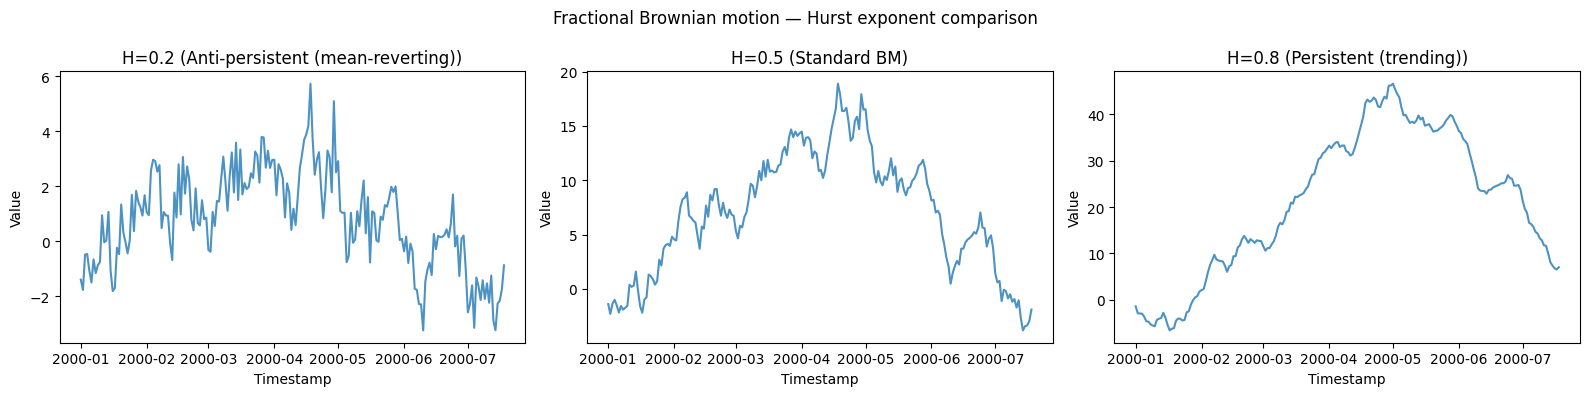

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (hurst, behavior) in zip(axes, zip(hurst_values, behaviors)):
    params = {
        "min_length": 200,
        "max_length": 200,
        "freq": "D",
        "hurst": hurst,
        "sigma": 1.0,
        "method": "cholesky",
        "seed": 42,
    }
    generator = FractionalBrownianMotionGenerator(engine="polars", **params)
    df = generator.generate(n_series=1)
    ax.plot(df["ds"].to_list(), df["y"].to_list(), alpha=0.8)
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Value")
    ax.set_title(f"H={hurst} ({behavior})")
plt.suptitle("Fractional Brownian motion — Hurst exponent comparison")
plt.tight_layout()
plt.show()

## Comparing fBm vs fGn (Increments)

Fractional Brownian motion (fBm) is the cumulative process, while fractional Gaussian noise (fGn) represents its increments.

In [ ]:
fbm_gen = FractionalBrownianMotionGenerator(engine="polars", 
    **{
        "min_length": 200,
        "max_length": 200,
        "freq": "D",
        "hurst": 0.7,
        "return_increments": False,
        "seed": 42,
    }
)
fbm_df = fbm_gen.generate(n_series=1)

fgn_gen = FractionalBrownianMotionGenerator(engine="polars", 
    **{
        "min_length": 200,
        "max_length": 200,
        "freq": "D",
        "hurst": 0.7,
        "return_increments": True,
        "seed": 42,
    }
)
fgn_df = fgn_gen.generate(n_series=1)

print(f"fBm mean: {fbm_df['y'].mean():.3f}, std: {fbm_df['y'].std():.3f}")
print(f"fGn mean: {fgn_df['y'].mean():.3f}, std: {fgn_df['y'].std():.3f}")

fBm mean: -16.055, std: 11.956
fGn mean: -0.231, std: 0.959


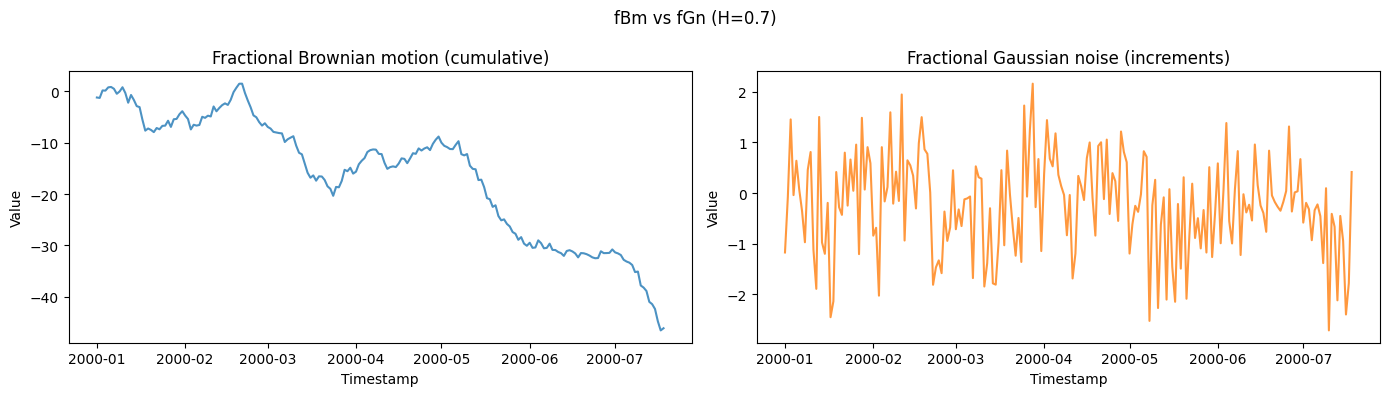

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(fbm_df["ds"].to_list(), fbm_df["y"].to_list(), alpha=0.8)
axes[0].set_xlabel("Timestamp")
axes[0].set_ylabel("Value")
axes[0].set_title("Fractional Brownian motion (cumulative)")
axes[1].plot(fgn_df["ds"].to_list(), fgn_df["y"].to_list(), alpha=0.8, color="tab:orange")
axes[1].set_xlabel("Timestamp")
axes[1].set_ylabel("Value")
axes[1].set_title("Fractional Gaussian noise (increments)")
plt.suptitle("fBm vs fGn (H=0.7)")
plt.tight_layout()
plt.show()

## Model information

Inspect the model parameters and metadata.

In [ ]:
info = fbm_gen.get_model_info()
for key, value in info.items():
    print(f"{key}: {value}")

hurst_exponent: 0.7
sigma: 1.0
behavior: persistent (trending)
long_range_dependence_exponent: 0.3999999999999999
method: fft
return_increments: False


::: {.callout-tip}
## Related generators

- [Random walk](../statistical/random_walk) — the `H = 0.5` special case.
- [Ornstein-Uhlenbeck](ornstein_uhlenbeck) — a different route to mean reversion.

The Hurst parameter is documented in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::